# Structural Severity Prediction Model

Multi-class classification to predict structural severity level.

- Target: `structural_severity` (Safe / Warning / Danger)
- Model: RandomForestClassifier

Run `Preprocessing-Pipeline.ipynb` first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, json, warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 1. Load Data

In [2]:
df = pd.read_csv('../data/preprocessed/structural_data.csv')
print(f'Structural data: {df.shape}')
print(f'\nTarget distribution:')
print(df['structural_severity'].value_counts())

Structural data: (16776, 48)

Target distribution:
structural_severity
Warning    16048
Danger       525
Safe         203
Name: count, dtype: int64


## 2. Feature Selection

In [3]:
structural_features = [
    'crack_width_mm', 'condition_score', 'roof_leak_flag',
    'building_age', 'flood_prone_area', 'crack_growth_rate',
    'condition_trend', 'deterioration_rate', 'urgency_score',
    'num_students', 'weeks_since_last_repair', 'days_since_repair',
    'repair_done', 'girls_school', 'water_leak', 'wiring_exposed', 'issue_flag',
]

material_cols = [c for c in df.columns if c.startswith('material_type_')]
weather_cols = [c for c in df.columns if c.startswith('weather_zone_')]
structural_features.extend(material_cols)
structural_features.extend(weather_cols)
structural_features = [f for f in structural_features if f in df.columns]

TARGET = 'structural_severity'
X = df[structural_features].fillna(0)

# encode target
le = LabelEncoder()
le.fit(['Safe', 'Warning', 'Danger'])
y = le.transform(df[TARGET])
target_names = le.classes_.tolist()

print(f'Features: {len(structural_features)}')
print(f'X: {X.shape}')
print(f'Classes: {target_names}')
for label, count in zip(*np.unique(y, return_counts=True)):
    print(f'  {target_names[label]}: {count}')

Features: 25
X: (16776, 25)
Classes: ['Danger', 'Safe', 'Warning']
  Danger: 525
  Safe: 203


## 3. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 13420, Test: 3356


## 4. Train Random Forest (Multi-class)

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)

print('Structural Model Results:')
print(f'  Accuracy:    {accuracy_score(y_test, y_pred):.4f}')
print(f'  Macro F1:    {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'  Weighted F1: {f1_score(y_test, y_pred, average="weighted"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=target_names))

Structural Model Results:
  Accuracy:    0.9991
  Macro F1:    0.9925
  Weighted F1: 0.9991

Classification Report:
              precision    recall  f1-score   support

      Danger       1.00      0.98      0.99       105
        Safe       1.00      0.98      0.99        41
     Warning       1.00      1.00      1.00      3210

    accuracy                           1.00      3356
   macro avg       1.00      0.99      0.99      3356
weighted avg       1.00      1.00      1.00      3356



In [6]:
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1_weighted')
print(f'5-Fold CV Weighted F1: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

5-Fold CV Weighted F1: [0.9997 0.9991 0.9997 0.9997 0.9982]
Mean: 0.9993 +/- 0.0006


## 5. Evaluation Plots

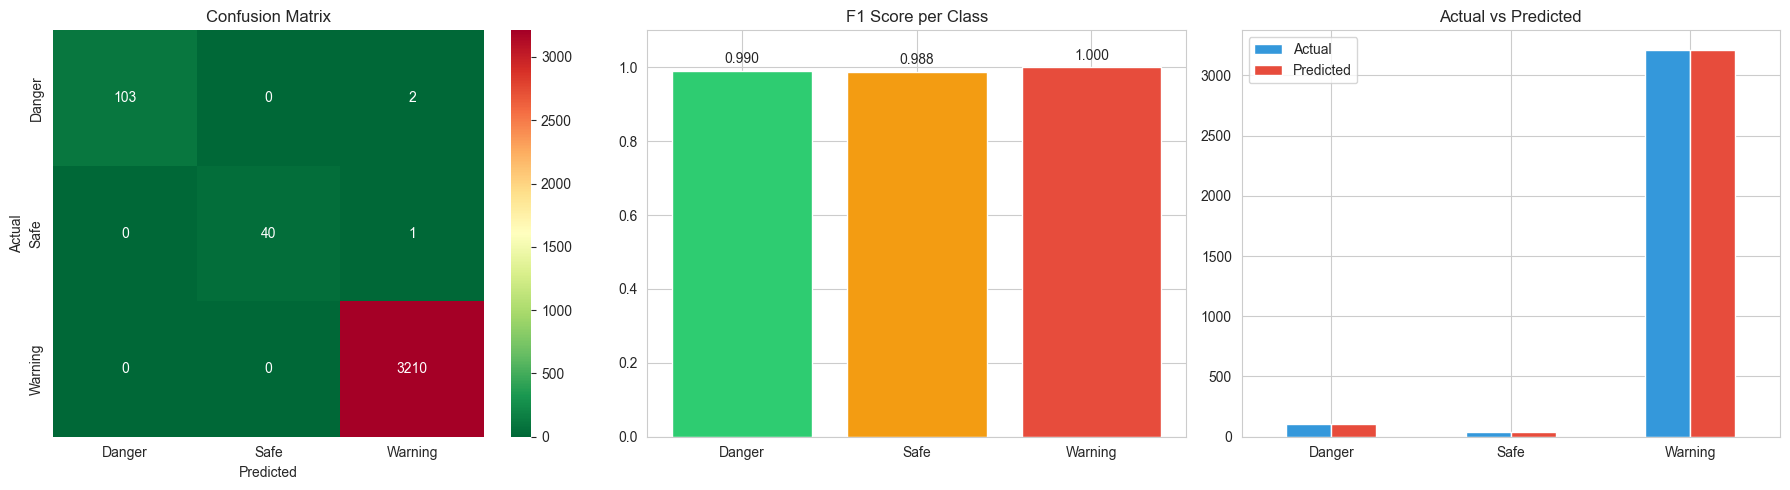

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# per-class F1
f1_per_class = f1_score(y_test, y_pred, average=None)
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(target_names, f1_per_class, color=colors)
axes[1].set_title('F1 Score per Class')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(f1_per_class):
    axes[1].text(i, v+0.02, f'{v:.3f}', ha='center')

# actual vs predicted distribution
pred_counts = pd.Series(y_pred).map({i: n for i,n in enumerate(target_names)}).value_counts()
actual_counts = pd.Series(y_test).map({i: n for i,n in enumerate(target_names)}).value_counts()
comp = pd.DataFrame({'Actual': actual_counts, 'Predicted': pred_counts}).loc[target_names]
comp.plot(kind='bar', ax=axes[2], color=['#3498db','#e74c3c'], rot=0)
axes[2].set_title('Actual vs Predicted')

plt.tight_layout()
plt.show()

## 6. Feature Importance and Explainability

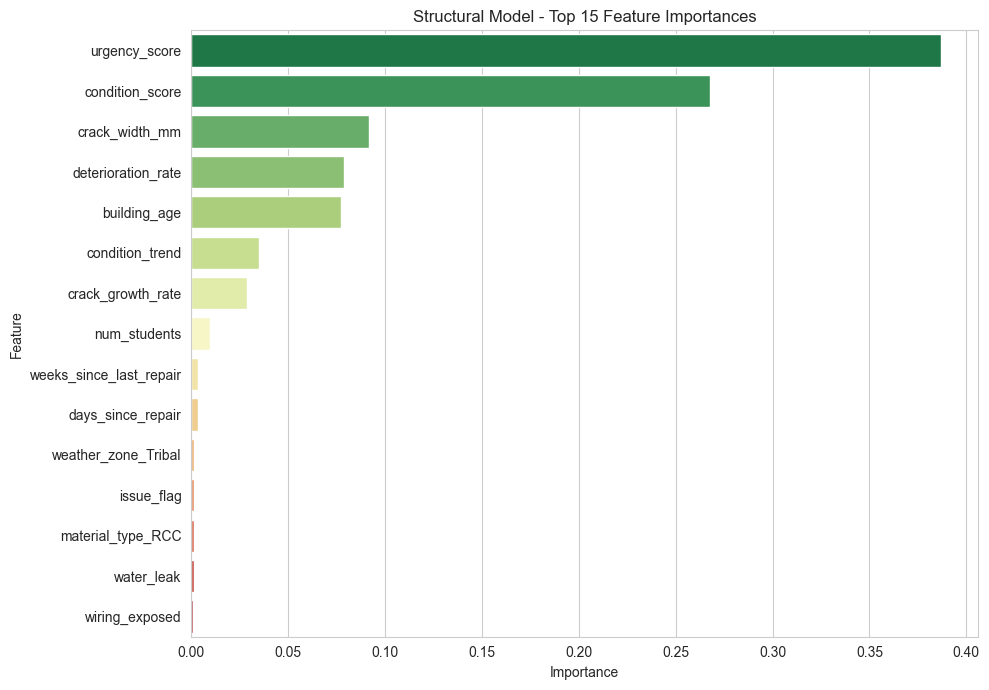

Top 10 features:
  urgency_score                  0.3868
  condition_score                0.2679
  crack_width_mm                 0.0918
  deterioration_rate             0.0790
  building_age                   0.0775
  condition_trend                0.0351
  crack_growth_rate              0.0285
  num_students                   0.0099
  weeks_since_last_repair        0.0035
  days_since_repair              0.0034


In [8]:
feat_imp = pd.DataFrame({
    'Feature': structural_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', palette='RdYlGn_r')
plt.title('Structural Model - Top 15 Feature Importances')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for _, row in feat_imp.head(10).iterrows():
    print(f"  {row['Feature']:30s} {row['Importance']:.4f}")

In [9]:
def explain_structural(model, features, feature_names, label_enc, top_n=5):
    """Returns prediction with explanation for structural severity."""
    arr = np.array(features).reshape(1, -1)
    pred = model.predict(arr)[0]
    prob = model.predict_proba(arr)[0]
    label = label_enc.inverse_transform([pred])[0]

    class_probs = {label_enc.inverse_transform([i])[0]: round(float(p), 4)
                   for i, p in enumerate(prob)}

    imp = model.feature_importances_
    top = sorted(zip(feature_names, features, imp), key=lambda x: x[2], reverse=True)[:top_n]

    labels = {
        'crack_width_mm': 'significant cracks',
        'condition_score': 'poor condition',
        'building_age': 'aging structure',
        'crack_growth_rate': 'rapid crack growth',
        'condition_trend': 'declining trend',
        'deterioration_rate': 'fast deterioration',
        'flood_prone_area': 'flood-prone location',
        'roof_leak_flag': 'roof leakage',
    }
    reasons = [labels.get(f[0], f[0]) for f in top[:3]]

    return {
        'prediction': label,
        'class_probabilities': class_probs,
        'top_features': [{'name': f[0], 'importance': round(float(f[2]), 4)} for f in top],
        'explanation': f"{label} severity due to: {', '.join(reasons)}."
    }

sample = X_test.iloc[0].values
result = explain_structural(rf_model, sample, structural_features, le)
print('Example prediction:')
print(json.dumps(result, indent=2))

Example prediction:
{
  "prediction": "Warning",
  "class_probabilities": {
    "Danger": 0.0,
    "Safe": 0.0,
    "Warning": 1.0
  },
  "top_features": [
    {
      "name": "urgency_score",
      "importance": 0.3868
    },
    {
      "name": "condition_score",
      "importance": 0.2679
    },
    {
      "name": "crack_width_mm",
      "importance": 0.0918
    },
    {
      "name": "deterioration_rate",
      "importance": 0.079
    },
    {
      "name": "building_age",
      "importance": 0.0775
    }
  ],
  "explanation": "Warning severity due to: urgency_score, poor condition, significant cracks."
}


## 7. Save Model

In [10]:
os.makedirs('../models', exist_ok=True)

joblib.dump(rf_model, '../models/structural_model.pkl')
joblib.dump(structural_features, '../models/structural_features.pkl')
joblib.dump(le, '../models/structural_label_encoder.pkl')

metrics_dict = {
    'model': 'RandomForestClassifier',
    'category': 'structural',
    'target': TARGET,
    'classes': target_names,
    'n_features': len(structural_features),
    'accuracy': round(float(accuracy_score(y_test, y_pred)), 4),
    'macro_f1': round(float(f1_score(y_test, y_pred, average='macro')), 4),
    'weighted_f1': round(float(f1_score(y_test, y_pred, average='weighted')), 4),
    'cv_mean_f1': round(float(cv_scores.mean()), 4),
    'per_class_f1': {n: round(float(f), 4) for n, f in zip(target_names, f1_per_class)},
    'features': structural_features
}
with open('../models/structural_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print('Structural model saved to models/')
print(f'  Accuracy:    {metrics_dict["accuracy"]}')
print(f'  Weighted F1: {metrics_dict["weighted_f1"]}')

Structural model saved to models/
  Accuracy:    0.9991
  Weighted F1: 0.9991
